<a href="https://colab.research.google.com/github/princesapkota/worksheets6thsem/blob/main/week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Part 1: Denoising Autoencoder with MNIST


## Step 1: Load, Pre-process, and Add Noise to the Dataset



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Load and preprocess MNIST
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

# Generate noisy versions
noise_factor_low = 0.1
noise_factor_high = 0.5

x_train_noisy_low = x_train + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_train_noisy_high = x_train + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy_low = x_test + noise_factor_low * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
x_test_noisy_high = x_test + noise_factor_high * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Clip pixel values to [0, 1]
x_train_noisy_low = np.clip(x_train_noisy_low, 0., 1.)
x_test_noisy_low = np.clip(x_test_noisy_low, 0., 1.)
x_train_noisy_high = np.clip(x_train_noisy_high, 0., 1.)
x_test_noisy_high = np.clip(x_test_noisy_high, 0., 1.)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


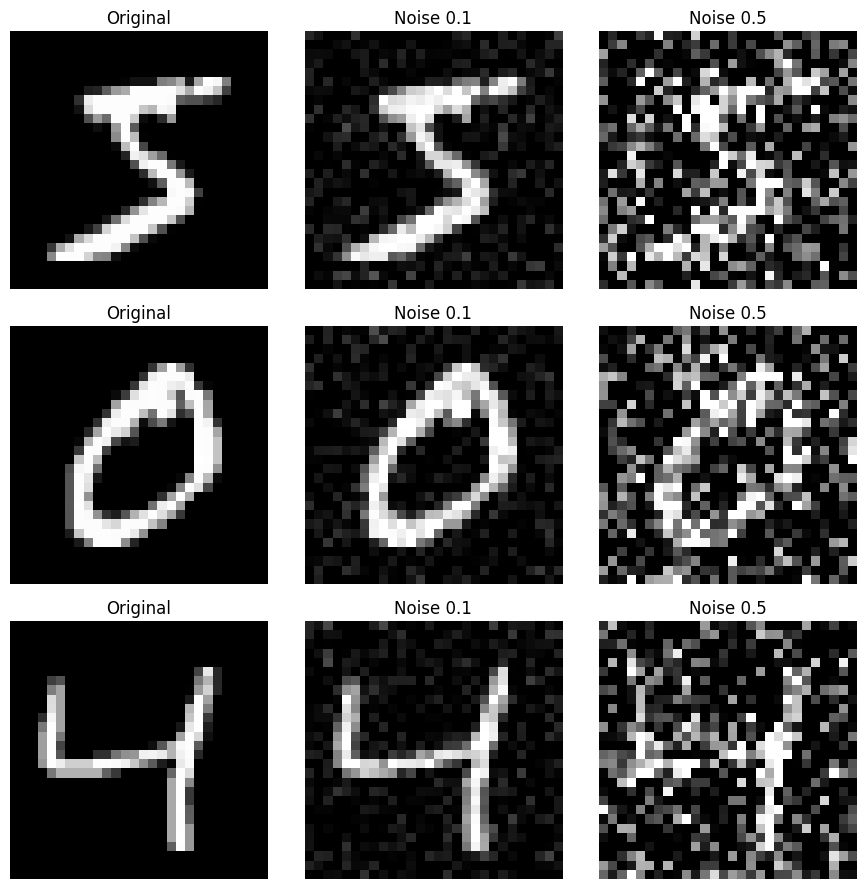

In [2]:
# Visualize in a 3 x 3 grid
n = 3  # number of images to show
plt.figure(figsize=(9, 9))
for i in range(n):
    # Original image
    ax = plt.subplot(n, 3, i * 3 + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Low noise image
    ax = plt.subplot(n, 3, i * 3 + 2)
    plt.imshow(x_train_noisy_low[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.1")
    plt.axis('off')

    # High noise image
    ax = plt.subplot(n, 3, i * 3 + 3)
    plt.imshow(x_train_noisy_high[i].reshape(28, 28), cmap='gray')
    plt.title("Noise 0.5")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Step 2: Build the Convolutional Denoising Autoencoder Model

**Architecture:**
- **Encoder:** Conv2D + ReLU → MaxPooling → Conv2D + ReLU → MaxPooling
- **Decoder:** Conv2D + ReLU → UpSampling → Conv2D + ReLU → UpSampling → Conv2D + Sigmoid
- **Loss:** Binary Crossentropy
- **Optimizer:** Adam

In [3]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Encoder
def build_encoder(input_shape=(28, 28, 1)):
    """
    Builds the encoder part of the convolutional autoencoder.

    Parameters:
        input_shape (tuple): Shape of the input image. Default is (28, 28, 1) for MNIST.

    Returns:
        input_img (Keras Input): Input layer of the model.
        encoded (Keras Tensor): Encoded representation after convolution and pooling.
    """
    input_img = Input(shape=input_shape, name="input")
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same', name="encoded")(x)
    return input_img, encoded

# Decoder
def build_decoder(encoded_input):
    """
    Builds the decoder part of the convolutional autoencoder.

    Parameters:
        encoded_input (Keras Tensor): The output from the encoder.

    Returns:
        decoded (Keras Tensor): The reconstructed output after upsampling and convolution.
    """
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(encoded_input)
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)
    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoded")(x)
    return decoded

# Complete Autoencoder
def build_autoencoder():
    """
    Constructs and compiles the full convolutional autoencoder by connecting encoder and decoder.

    Returns:
        autoencoder (Keras Model): Compiled autoencoder model.
    """
    input_img, encoded_output = build_encoder()
    decoded_output = build_decoder(encoded_output)
    autoencoder = Model(inputs=input_img, outputs=decoded_output, name="autoencoder")
    autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')
    return autoencoder

In [4]:
# Build and display model summary
autoencoder = build_autoencoder()
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (MaxPooling2D)          │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoded (Conv2D)                │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

## Step 3: Train the Autoencoder

Train with noisy images as input and clean images as the target.

In [5]:
# Build the autoencoder from previous steps
autoencoder = build_autoencoder()

# Train with noisy input and clean target
history = autoencoder.fit(
    x_train_noisy_high, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy_high, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 190s 400ms/step - loss: 0.1607 - val_loss: 0.1146
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 187s 398ms/step - loss: 0.1112 - val_loss: 0.1065
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 189s 403ms/step - loss: 0.1056 - val_loss: 0.1026
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 196s 389ms/step - loss: 0.1024 - val_loss: 0.1004
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 186s 396ms/step - loss: 0.1006 - val_loss: 0.0992
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 199s 390ms/step - loss: 0.0994 - val_loss: 0.0983
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 185s 395ms/step - loss: 0.0984 - val_loss: 0.0979
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 182s 388ms/step - loss: 0.0976 - val_loss: 0.0967
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 186s 396ms/step - loss: 0.0969 - val_loss: 0.0961
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 187s 398ms/step - loss: 0.0963 - val_loss: 0.0956


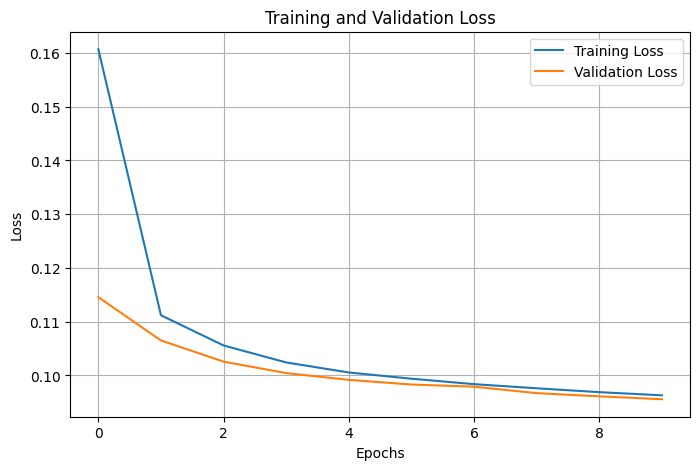

In [6]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Step 4: Evaluate the Autoencoder

Visualize noisy, denoised, and clean images side by side.

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step


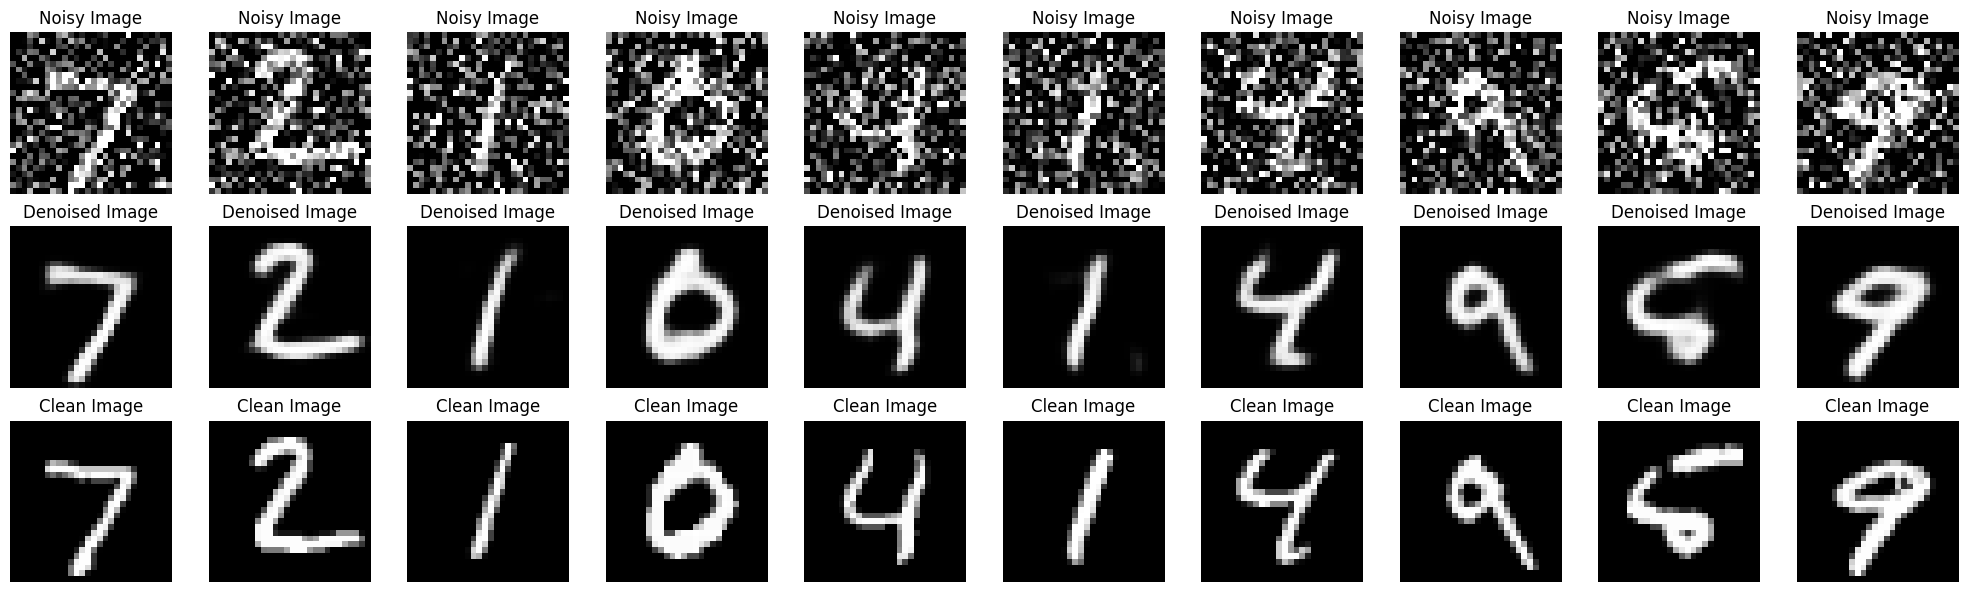

In [8]:
# Predict the denoised images from noisy test images
denoised_images = autoencoder.predict(x_test_noisy_high)

# Function to display images
def plot_images(noisy_images, denoised_images, clean_images, n=10):
    plt.figure(figsize=(20, 6))
    for i in range(n):
        # Plot noisy images
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy_images[i].reshape(28, 28), cmap='gray')
        plt.title("Noisy Image")
        plt.axis('off')

        # Plot denoised images
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
        plt.title("Denoised Image")
        plt.axis('off')

        # Plot clean images
        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(clean_images[i].reshape(28, 28), cmap='gray')
        plt.title("Clean Image")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Display the first 10 images
plot_images(x_test_noisy_high, denoised_images, x_test, n=10)

---
# Part 2: Exercise — Denoising Convolutional Autoencoder on Devnagari Handwritten Digit Dataset

**Objective:** Build a Denoising Convolutional Autoencoder with at least 4 layers deep to remove noise from images in the Devnagari Handwritten dataset.

## Step 0: Mount Google Drive

Mount your Google Drive to access the Devnagari dataset.

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 1: Load and Preprocess the Devnagari Dataset

Adjust the `dataset_path` variable below to point to your Devnagari dataset folder in Google Drive.

In [11]:
import zipfile

zip_path = '/content/drive/MyDrive/AI ML/Data/Copy of devnagari digit.zip'
extract_path = '/content/devnagari_dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted")
print(os.listdir(extract_path))

Extracted
['DevanagariHandwrittenDigitDataset']


In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

dataset_path = '/content/devnagari_dataset/DevanagariHandwrittenDigitDataset/Train'# Load images from subdirectories (each subfolder = one class)
images = []
labels = []

for class_folder in sorted(os.listdir(dataset_path)):
    class_path = os.path.join(dataset_path, class_folder)
    if not os.path.isdir(class_path):
        continue
    for img_file in os.listdir(class_path):
        img_path = os.path.join(class_path, img_file)
        try:
            img = Image.open(img_path).convert('L')  # Convert to grayscale
            img = img.resize((32, 32))  # Resize to a uniform size
            images.append(np.array(img))
            labels.append(class_folder)
        except Exception as e:
            pass

images = np.array(images)
labels = np.array(labels)
print(f"Loaded {len(images)} images with shape: {images.shape}")

Loaded 17000 images with shape: (17000, 32, 32)


In [15]:
# Normalize to [0, 1]
images = images.astype('float32') / 255.0

# Add channel dimension: (N, 32, 32) -> (N, 32, 32, 1)
images = np.reshape(images, (len(images), 32, 32, 1))

# Split into training and validation sets
x_train, x_val = train_test_split(images, test_size=0.2, random_state=42)
print(f"Training set: {x_train.shape}, Validation set: {x_val.shape}")

Training set: (13600, 32, 32, 1), Validation set: (3400, 32, 32, 1)


In [16]:
# Add Gaussian noise
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_val_noisy = x_val + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_val.shape)

# Clip to [0, 1]
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_val_noisy = np.clip(x_val_noisy, 0., 1.)

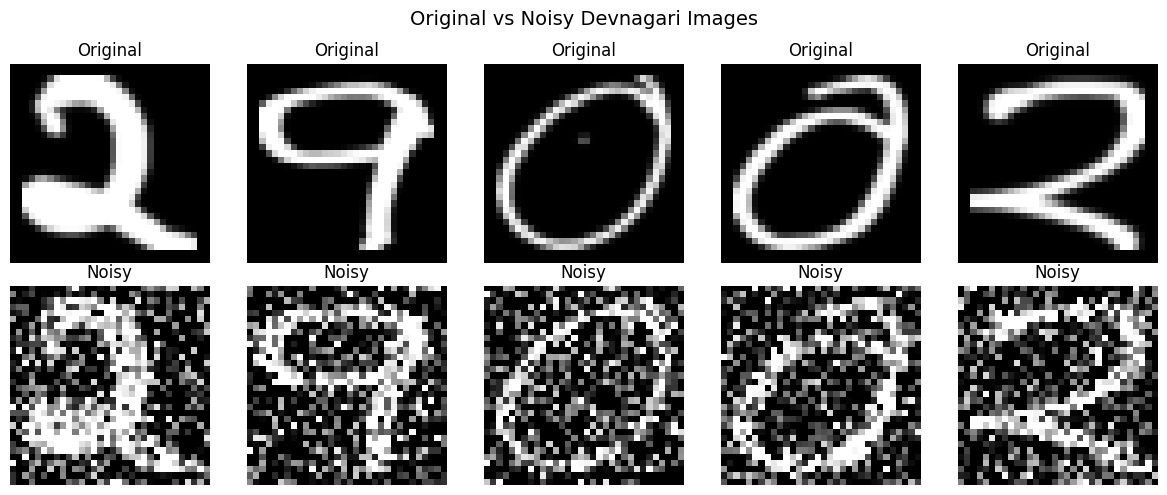

In [17]:
# Visualize original vs noisy
n = 5
plt.figure(figsize=(12, 5))
for i in range(n):
    # Original
    plt.subplot(2, n, i + 1)
    plt.imshow(x_train[i].reshape(32, 32), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_train_noisy[i].reshape(32, 32), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

plt.suptitle("Original vs Noisy Devnagari Images", fontsize=14)
plt.tight_layout()
plt.show()

## Step 2: Build the Deep Convolutional Denoising Autoencoder (4+ Layers)

The encoder uses 4 convolutional layers with max-pooling, and the decoder mirrors it with upsampling.

In [18]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def build_deep_autoencoder(input_shape=(32, 32, 1)):
    """
    Builds a deep convolutional denoising autoencoder with 4+ conv layers
    in both the encoder and decoder.
    """
    # ---- ENCODER ----
    input_img = Input(shape=input_shape, name="input")

    # Layer 1
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2), padding='same')(x)  # 32x32 -> 16x16

    # Layer 2
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2), padding='same')(x)  # 16x16 -> 8x8

    # Layer 3
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2), padding='same')(x)  # 8x8 -> 4x4

    # Layer 4 (Bottleneck)
    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    encoded = BatchNormalization(name='encoded')(x)  # 4x4x256

    # ---- DECODER ----
    # Layer 1
    x = Conv2D(256, (3, 3), activation='relu', padding='same')(encoded)
    x = BatchNormalization()(x)
    x = UpSampling2D((2, 2))(x)  # 4x4 -> 8x8

    # Layer 2
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = UpSampling2D((2, 2))(x)  # 8x8 -> 16x16

    # Layer 3
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = UpSampling2D((2, 2))(x)  # 16x16 -> 32x32

    # Layer 4 (Output)
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name='decoded')(x)

    # Build and compile
    autoencoder = Model(inputs=input_img, outputs=decoded, name='deep_denoising_autoencoder')
    autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy')

    return autoencoder

# Build the model
autoencoder_dev = build_deep_autoencoder()
autoencoder_dev.summary()

Model: "deep_denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoded (BatchNormalization)    │ (None, 4, 4, 256)      │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 4, 4, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 32)     │        18,46

 Total params: 1,369,217 (5.22 MB)

 Trainable params: 1,367,361 (5.22 MB)

 Non-trainable params: 1,856 (7.25 KB)

## Step 3: Train the Denoising Autoencoder

In [20]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

# Train the model
history_dev = autoencoder_dev.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_val_noisy, x_val),
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 286s 3s/step - loss: 0.2099 - val_loss: 1.7213 - learning_rate: 0.0010
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 261s 2s/step - loss: 0.1558 - val_loss: 2.0372 - learning_rate: 0.0010
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 259s 2s/step - loss: 0.1473 - val_loss: 0.8859 - learning_rate: 0.0010
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 272s 3s/step - loss: 0.1429 - val_loss: 0.2359 - learning_rate: 0.0010
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 320s 3s/step - loss: 0.1391 - val_loss: 0.1556 - learning_rate: 0.0010
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 264s 2s/step - loss: 0.1365 - val_loss: 0.1465 - learning_rate: 0.0010
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 322s 2s/step - loss: 0.1339 - val_loss: 0.1460 - learning_rate: 0.0010
Epoch 8/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 266s 2s/step - loss: 0.1335 - val_loss: 0.1442 - learning_rate: 0.0010
Epoch 9/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 326s 3s/step - loss: 0.1310 - val_loss: 0.1433 - learning_rate: 0.0010
E

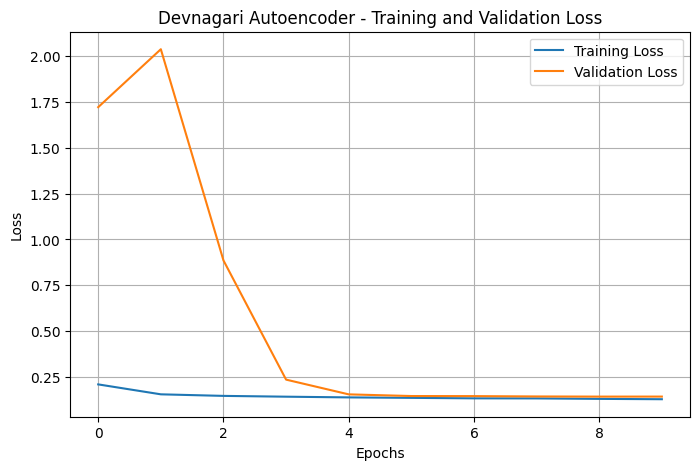

In [21]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history_dev.history['loss'], label='Training Loss')
plt.plot(history_dev.history['val_loss'], label='Validation Loss')
plt.title('Devnagari Autoencoder - Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

## Step 4: Evaluate and Visualize Results

107/107 ━━━━━━━━━━━━━━━━━━━━ 16s 140ms/step


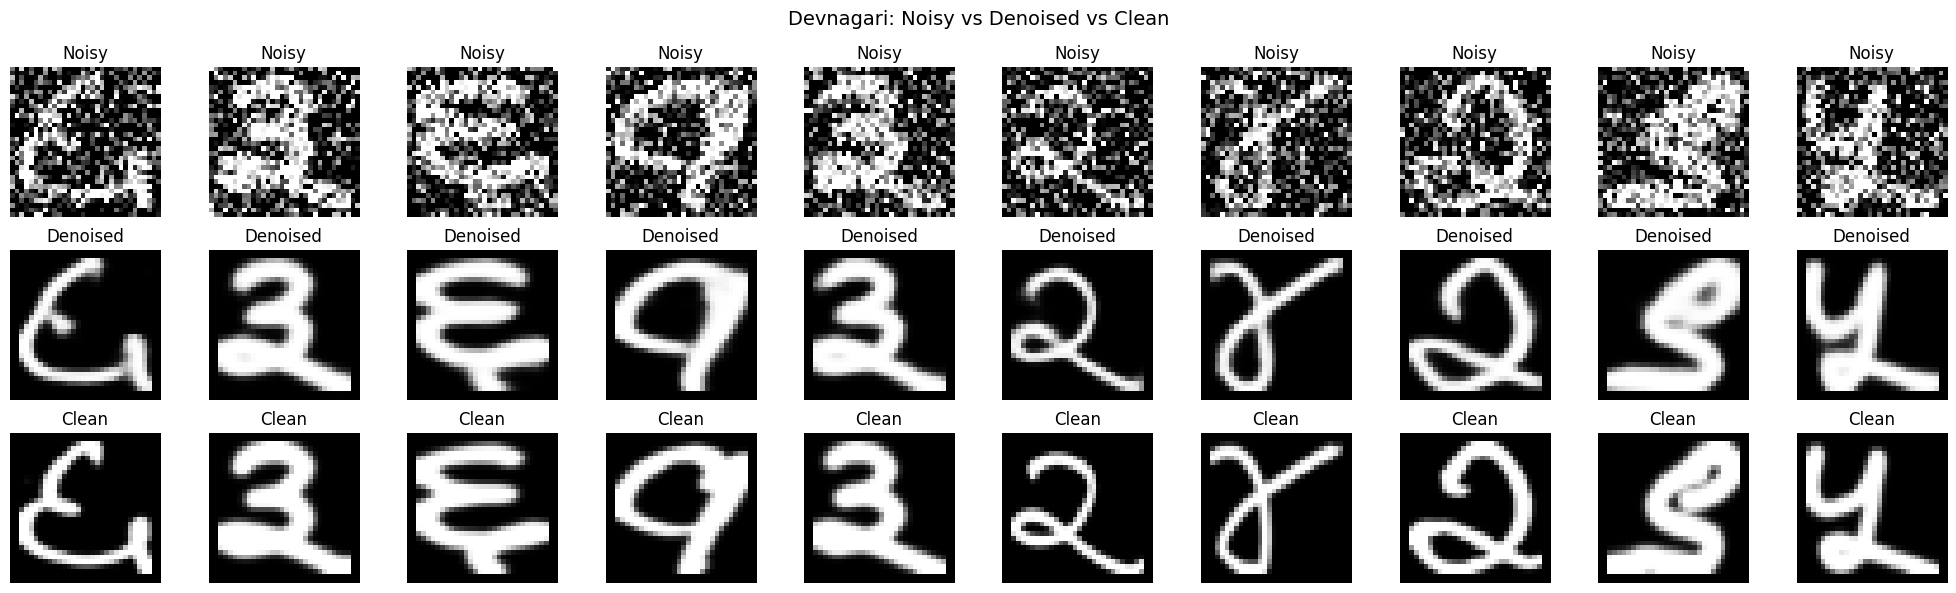

In [22]:
# Predict denoised images
denoised_dev = autoencoder_dev.predict(x_val_noisy)

# Visualize: Noisy → Denoised → Clean
n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    # Noisy
    plt.subplot(3, n, i + 1)
    plt.imshow(x_val_noisy[i].reshape(32, 32), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Denoised
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(denoised_dev[i].reshape(32, 32), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

    # Clean
    plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(x_val[i].reshape(32, 32), cmap='gray')
    plt.title("Clean")
    plt.axis('off')

plt.suptitle("Devnagari: Noisy vs Denoised vs Clean", fontsize=14)
plt.tight_layout()
plt.show()

## Step 5: Experiment and Fine-Tune

Try different configurations and record observations.

Epoch 1/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 282s 3s/step - loss: 0.2000 - val_loss: 1.6799 - learning_rate: 0.0010
Epoch 2/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 328s 3s/step - loss: 0.1406 - val_loss: 1.8940 - learning_rate: 0.0010
Epoch 3/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 269s 3s/step - loss: 0.1326 - val_loss: 0.7689 - learning_rate: 0.0010
Epoch 4/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 321s 3s/step - loss: 0.1284 - val_loss: 0.1917 - learning_rate: 0.0010
Epoch 5/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 317s 2s/step - loss: 0.1260 - val_loss: 0.1408 - learning_rate: 0.0010
Epoch 6/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 269s 3s/step - loss: 0.1243 - val_loss: 0.1293 - learning_rate: 0.0010
Epoch 7/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 315s 2s/step - loss: 0.1225 - val_loss: 0.1321 - learning_rate: 0.0010
Epoch 8/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 323s 2s/step - loss: 0.1218 - val_loss: 0.1258 - learning_rate: 0.0010
Epoch 9/10
107/107 ━━━━━━━━━━━━━━━━━━━━ 260s 2s/step - loss: 0.1210 - val_loss: 0.1273 - learning_rate: 0.0010
E

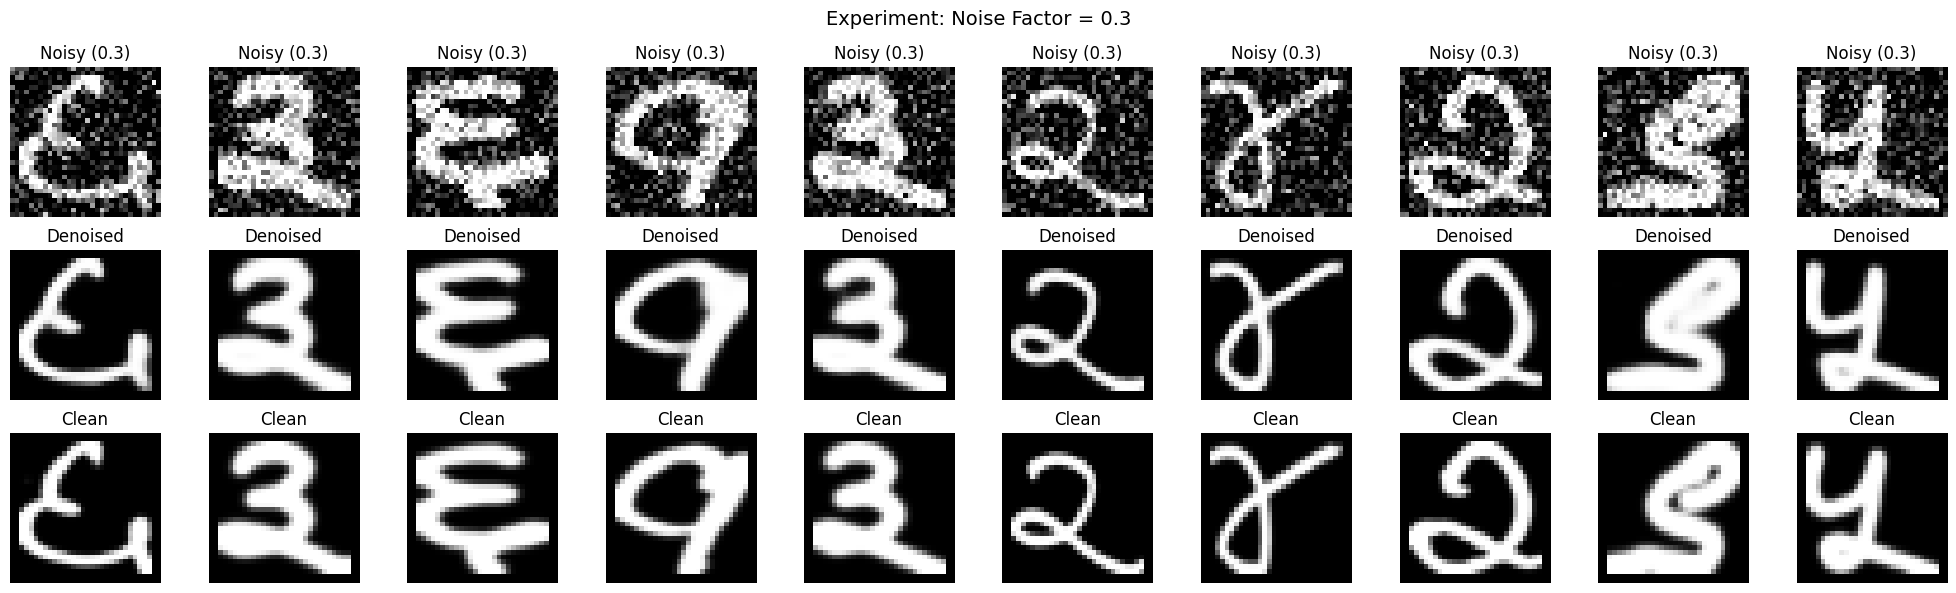

In [23]:
# Experiment: Train with a lower noise factor and compare
noise_factor_exp = 0.3

x_train_noisy_exp = x_train + noise_factor_exp * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_val_noisy_exp = x_val + noise_factor_exp * np.random.normal(loc=0.0, scale=1.0, size=x_val.shape)
x_train_noisy_exp = np.clip(x_train_noisy_exp, 0., 1.)
x_val_noisy_exp = np.clip(x_val_noisy_exp, 0., 1.)

# Build a fresh model
autoencoder_exp = build_deep_autoencoder()

history_exp = autoencoder_exp.fit(
    x_train_noisy_exp, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_val_noisy_exp, x_val),
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
    ]
)

# Compare results
denoised_exp = autoencoder_exp.predict(x_val_noisy_exp)

n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    plt.subplot(3, n, i + 1)
    plt.imshow(x_val_noisy_exp[i].reshape(32, 32), cmap='gray')
    plt.title("Noisy (0.3)")
    plt.axis('off')

    plt.subplot(3, n, i + 1 + n)
    plt.imshow(denoised_exp[i].reshape(32, 32), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

    plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(x_val[i].reshape(32, 32), cmap='gray')
    plt.title("Clean")
    plt.axis('off')

plt.suptitle("Experiment: Noise Factor = 0.3", fontsize=14)
plt.tight_layout()
plt.show()

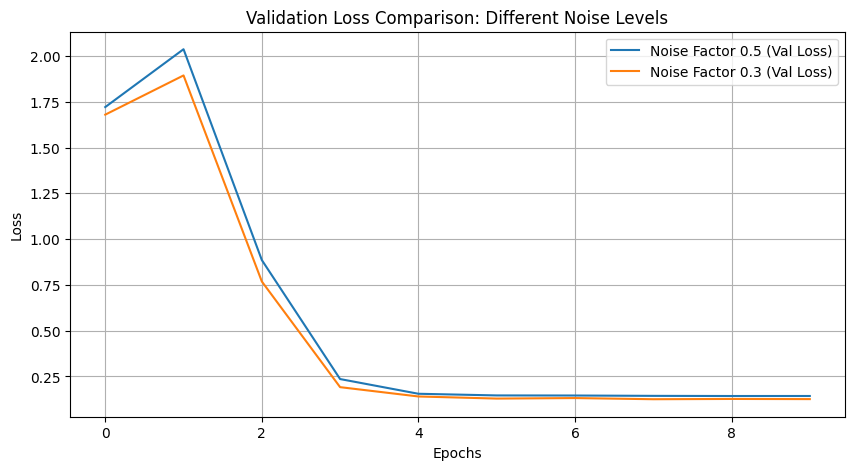

Observations:
  Final val loss (noise=0.5): 0.1435
  Final val loss (noise=0.3): 0.1264


In [24]:
# Compare loss curves for both noise levels
plt.figure(figsize=(10, 5))
plt.plot(history_dev.history['val_loss'], label='Noise Factor 0.5 (Val Loss)')
plt.plot(history_exp.history['val_loss'], label='Noise Factor 0.3 (Val Loss)')
plt.title('Validation Loss Comparison: Different Noise Levels')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

print("Observations:")
print(f"  Final val loss (noise=0.5): {history_dev.history['val_loss'][-1]:.4f}")
print(f"  Final val loss (noise=0.3): {history_exp.history['val_loss'][-1]:.4f}")